## CAKE Framework

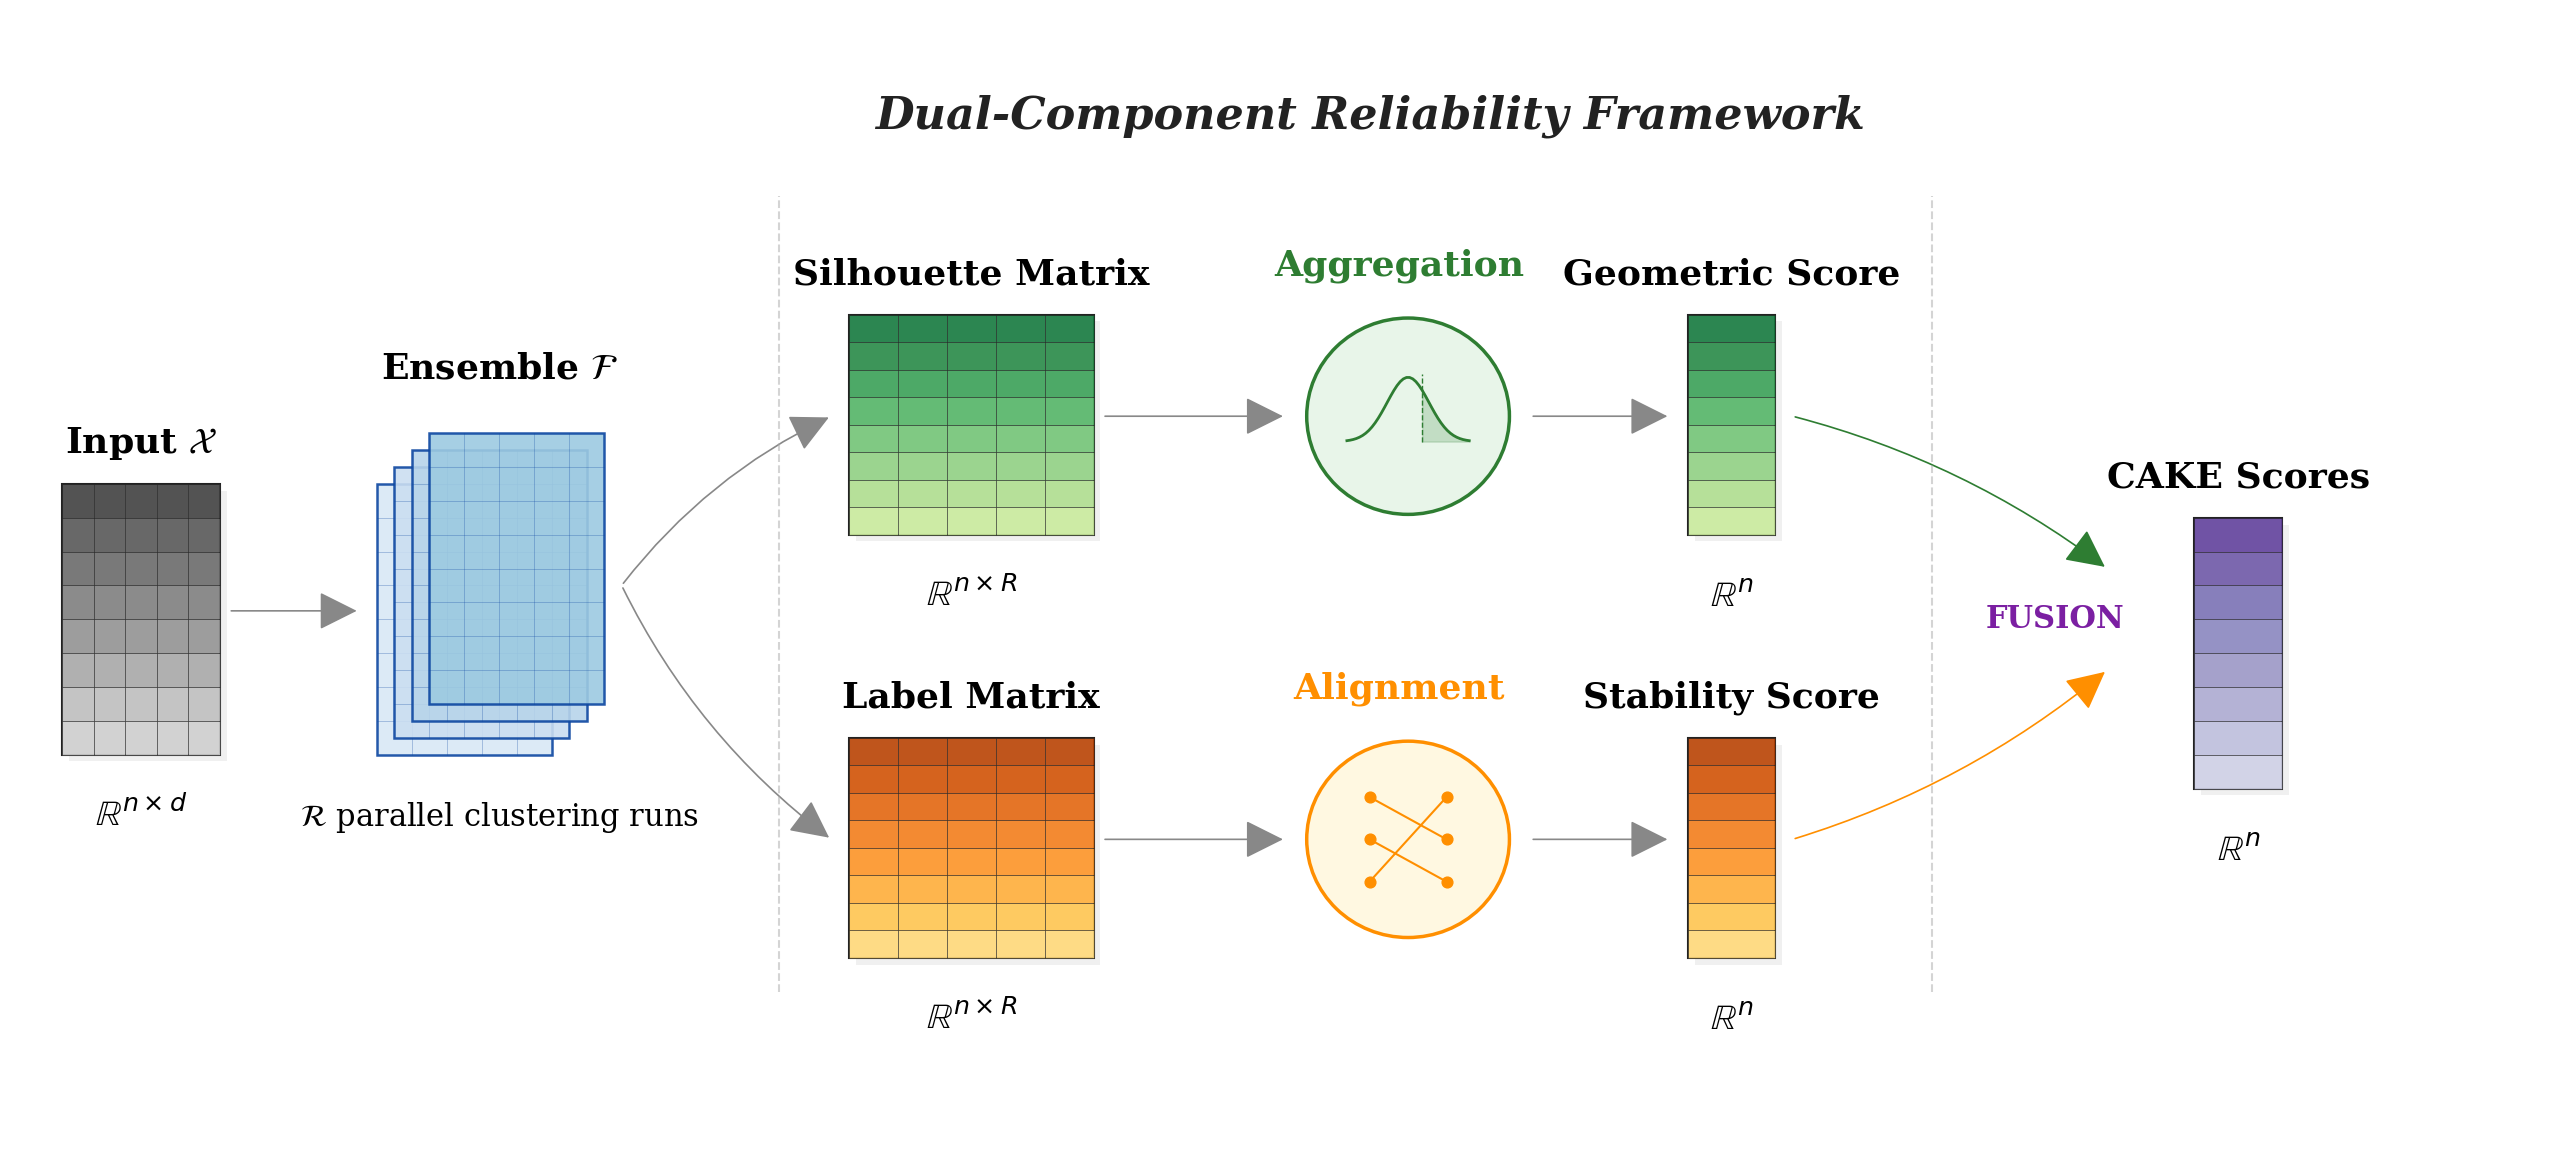

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.font_manager as fm
import numpy as np

font_names = [f.name for f in fm.fontManager.ttflist]
font_family = 'Times New Roman' if 'Times New Roman' in font_names else 'DejaVu Serif'
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': [font_family],
    'font.size': 22,
    'text.usetex': False
})

fig, ax = plt.subplots(figsize=(26, 12))
ax.set_xlim(0, 145)
ax.set_ylim(-5, 62)
ax.axis('off')

def draw_matrix(x, y, w, h, rows=8, cols=5, cmap_name='YlGnBu', label=None, sublabel=None, zorder=1):
    ax.add_patch(patches.Rectangle((x+0.4, y-0.4), w, h, fc='#000000', alpha=0.06, zorder=zorder-1))
    ax.add_patch(patches.Rectangle((x, y), w, h, lw=1.5, ec='#222222', fc='white', zorder=zorder))
    cmap = plt.get_cmap(cmap_name)
    cw, ch = w/cols, h/rows
    for r in range(rows):
        val = 0.3 + (0.5 * (r / (rows - 1)))
        for c in range(cols):
            ax.add_patch(patches.Rectangle((x + c*cw, y + r*ch), cw, ch,
                                           fc=cmap(val), ec='#222222', lw=0.4, alpha=0.9, zorder=zorder+1))
    if label:
        ax.text(x + w/2, y + h + 1.8, label, ha='center', fontweight='bold', fontsize=26)
    if sublabel:
        ax.text(x + w/2, y - 4.2, sublabel, ha='center', style='normal', fontsize=26, color='#000000', fontweight='bold')

def draw_3d_ensemble(x, y, w, h, layers=4):
    for i in range(layers):
        off = i * 1.0
        color = plt.cm.Blues(0.15 + (i/layers)*0.3)
        ax.add_patch(patches.Rectangle((x+off, y+off), w, h, lw=1.8, ec='#0D47A1', fc=color, alpha=0.9, zorder=i))
        for g in range(1, 8):
            ax.plot([x+off, x+off+w], [y+off+g*h/8, y+off+g*h/8], c='#0D47A1', lw=0.5, alpha=0.4, zorder=i+0.1)
        for g in range(1, 5):
            ax.plot([x+off+g*w/5, x+off+g*w/5], [y+off, y+off+h], c='#0D47A1', lw=0.5, alpha=0.4, zorder=i+0.1)
    ax.text(x+w/2+layers/2, y+h+layers+2.2, r"Ensemble $\mathcal{F}$", ha='center', fontweight='bold', fontsize=26)
    ax.text(x+w/2+layers/2, y - 4.2, r"$\mathcal{R}$ parallel clustering runs", ha='center', fontsize=22, color='#000000')
    return (x+w+layers, y+h/2+layers/2)

def draw_premium_op(x, y, op_type="stat", label_text="", color='#FFFFFF', edge='#222222'):
    radius = 5.8
    ax.add_patch(patches.Circle((x, y), radius, lw=2.5, ec=edge, fc=color, zorder=20))
    ax.text(x-0.5, y + radius + 2.5, label_text, ha='center', fontweight='bold', fontsize=26, color=edge)
    if op_type == "stat":
        qx = np.linspace(x-3.5, x+3.5, 40)
        qy = y - 1.5 + 3.8 * np.exp(-(qx-x)**2 / (2 * 1.2**2))
        ax.plot(qx, qy, color=edge, lw=2, zorder=21)
        ax.fill_between(qx, y-1.5, qy, where=(qx > x+0.8), color=edge, alpha=0.2, zorder=21)
        ax.plot([x+0.8, x+0.8], [y-1.5, y+2.5], color=edge, lw=1, ls='--', zorder=22)
    elif op_type == "mapping":
        nodes_left = [y+2.5, y, y-2.5]; nodes_right = [y+2.5, y, y-2.5]
        for nl in nodes_left: ax.scatter(x-2.2, nl, s=60, c=edge, zorder=22)
        for nr in nodes_right: ax.scatter(x+2.2, nr, s=60, c=edge, zorder=22)
        ax.plot([x-2.2, x+2.2], [nodes_left[0], nodes_right[1]], color=edge, lw=1.5, zorder=21)
        ax.plot([x-2.2, x+2.2], [nodes_left[1], nodes_right[2]], color=edge, lw=1.5, zorder=21)
        ax.plot([x-2.2, x+2.2], [nodes_left[2], nodes_right[0]], color=edge, lw=1.5, zorder=21)

def connect_hairline_final(p1, p2, rad=0, color='#888888'):
    arrow = patches.FancyArrowPatch(posA=p1, posB=p2, connectionstyle=f"arc3,rad={rad}",
                                    arrowstyle='-|> ,head_width=1.5,head_length=3',
                                    color=color, lw=1.2, mutation_scale=8, zorder=0)
    ax.add_patch(arrow)

# PIPELINE EXECUTION

# I. INPUT
draw_matrix(3, 18, 9, 16, cmap_name='Greys', label=r"Input $\mathcal{X}$", sublabel=r"$\mathbb{R}^{n \times d}$")
connect_hairline_final((12.5, 26.5), (20, 26.5))

# II. ENSEMBLE
p_ens = draw_3d_ensemble(21, 18, 10, 16)

# III. DUAL PATHWAYS (Shifted 10 units left)
draw_matrix(48, 31, 14, 13, cmap_name='YlGn', label="Silhouette Matrix", sublabel=r"$\mathbb{R}^{n \times R}$")
draw_premium_op(80, 38, op_type="stat", label_text=r"Aggregation", color='#E8F5E9', edge='#2E7D32')
draw_matrix(96, 31, 5.0, 13, cols=1, label="Geometric Score", sublabel=r"$\mathbb{R}^n$", cmap_name='YlGn')

draw_matrix(48, 6, 14, 13, cmap_name='YlOrBr', label="Label Matrix", sublabel=r"$\mathbb{R}^{n \times R}$")
draw_premium_op(80, 13, op_type="mapping", label_text="Alignment", color='#FFF8E1', edge='#FF8F00')
draw_matrix(96, 6, 5.0, 13, cols=1, label="Stability Score", sublabel=r"$\mathbb{R}^n$", cmap_name='YlOrBr')

# Connections (Shifted and shortened)
connect_hairline_final(p_ens, (47, 38), rad=-0.12)
connect_hairline_final(p_ens, (47, 13), rad=0.12)
connect_hairline_final((62.5, 38), (73, 38))
connect_hairline_final((62.5, 13), (73, 13))
connect_hairline_final((87, 38), (95, 38))
connect_hairline_final((87, 13), (95, 13))

# IV. FUSION
connect_hairline_final((102, 38), (120, 29), rad=-0.1, color='#2E7D32')
connect_hairline_final((102, 13), (120, 23), rad=0.1, color='#FF8F00')
ax.text(117, 26, "FUSION", ha='center', va='center', fontsize=22, fontweight='bold', color='#7B1FA2')

# CAKE COLUMN
draw_matrix(125, 16, 5.0, 16, cols=1, label="CAKE Scores", sublabel=r"$\mathbb{R}^n$", cmap_name='Purples')

# GLOBAL HEADER
ax.plot([44, 44], [4, 51], color='#AAAAAA', lw=1.5, ls='--', alpha=0.5)
ax.plot([110, 110], [4, 51], color='#AAAAAA', lw=1.5, ls='--', alpha=0.5)
ax.text(49.5, 55, "Dual-Component Reliability Framework", fontsize=32, color='#222222', style='italic', fontweight='bold')

plt.tight_layout()
plt.show()

## Component Failures

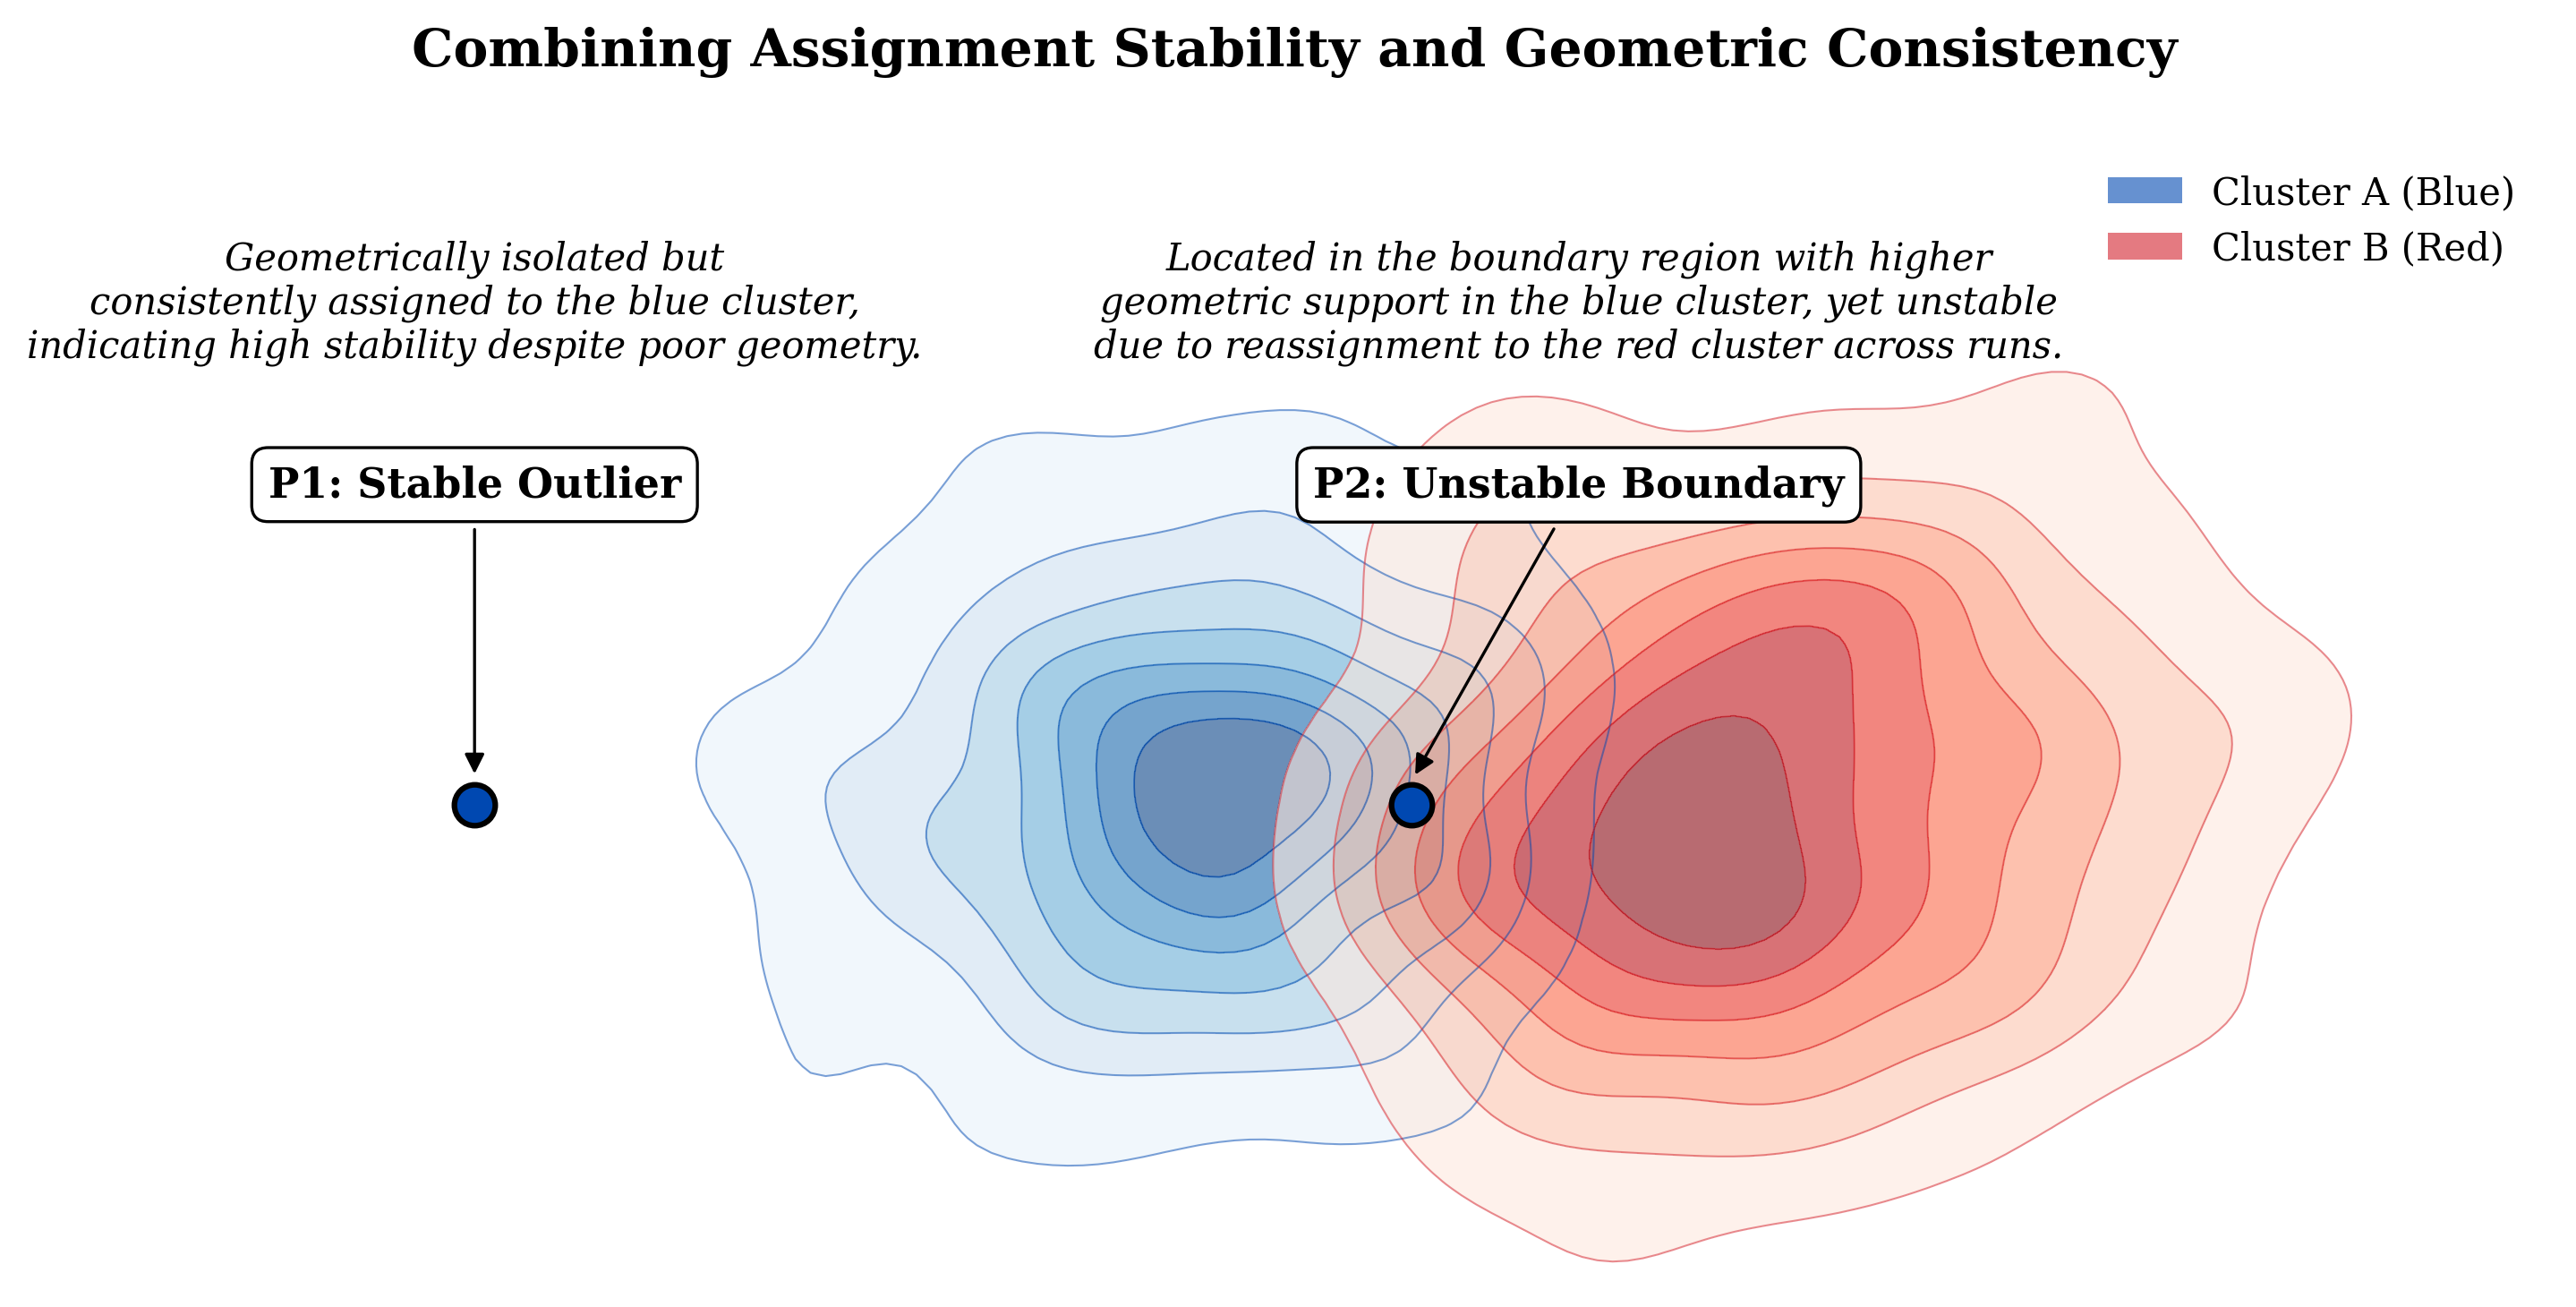

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
from scipy.stats import gaussian_kde
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

font_names = [f.name for f in fm.fontManager.ttflist]
if 'Times New Roman' in font_names:
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman']
elif 'DejaVu Serif' in font_names:
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['DejaVu Serif']
else:
    plt.rcParams['font.family'] = 'serif'

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'figure.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'text.usetex': False
})

np.random.seed(10)

def generate_filtered_cluster(loc_x, loc_y, scale, size, x_min=None, x_max=None):
    x_points = []
    y_points = []
    while len(x_points) < size:
        batch_size = size * 2
        x = np.random.normal(loc=loc_x, scale=scale, size=batch_size)
        y = np.random.normal(loc=loc_y, scale=scale, size=batch_size)

        mask = np.full(batch_size, True)
        if x_min is not None:
            mask &= (x > x_min)
        if x_max is not None:
            mask &= (x < x_max)

        x_points.extend(x[mask])
        y_points.extend(y[mask])

    return np.array(x_points[:size]), np.array(y_points[:size])

x1, y1 = generate_filtered_cluster(loc_x=2, loc_y=2, scale=0.6, size=500, x_max=3.0)
x2, y2 = generate_filtered_cluster(loc_x=3.6, loc_y=2, scale=0.7, size=500, x_min=2.4)

# CALCULATE KDE (Continuous Distributions)
xx, yy = np.mgrid[-2:7:200j, -1:5:200j]
positions = np.vstack([xx.ravel(), yy.ravel()])

# Cluster A Density
values_A = np.vstack([x1, y1])
kernel_A = gaussian_kde(values_A)
f_A = np.reshape(kernel_A(positions).T, xx.shape)

# Cluster B Density
values_B = np.vstack([x2, y2])
kernel_B = gaussian_kde(values_B)
f_B = np.reshape(kernel_B(positions).T, xx.shape)

# Setup
fig, ax = plt.subplots(figsize=(10, 5))

# white background
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# small circle
levels_A = np.linspace(0.02, f_A.max(), 8)
levels_B = np.linspace(0.02, f_B.max(), 8)

# Plot Continuous Distributions (Contours)
# Cluster A (Blue)
cset_A = ax.contourf(xx, yy, f_A, levels=levels_A, cmap='Blues', alpha=0.6)
ax.contour(xx, yy, f_A, levels=levels_A, colors=['#0048B1'], linewidths=0.5, alpha=0.5)

# Cluster B (Red)
cset_B = ax.contourf(xx, yy, f_B, levels=levels_B, cmap='Reds', alpha=0.6)
ax.contour(xx, yy, f_B, levels=levels_B, colors=['#D3212D'], linewidths=0.5, alpha=0.5)

# Add Legend Proxies
legend_handles = [
    Patch(facecolor='#0048B1', alpha=0.6, label='Cluster A (Blue)'),
    Patch(facecolor='#D3212D', alpha=0.6, label='Cluster B (Red)')
]

# Plot Special Points P1 & P2
p1_x, p1_y = -0.2, 2.0
ax.scatter([p1_x], [p1_y], color='#0048B1', s=120, edgecolors='black', linewidth=1.5, zorder=20)

p2_x, p2_y = 2.6, 2.0
ax.scatter([p2_x], [p2_y], color='#0048B1', s=120, edgecolors='black', linewidth=1.5, zorder=20)

# Annotate
bbox_title = dict(boxstyle="round,pad=0.4", fc="white", ec="black", alpha=1.0, linewidth=0.8)

bbox_text = dict(facecolor='none', edgecolor='none', pad=4)
arrow_style = dict(arrowstyle="-|>", connectionstyle="arc3,rad=0", color='black', linewidth=0.8)

# P1 Annotation
ax.annotate('P1: Stable Outlier',
            xy=(p1_x, p1_y + 0.1), xycoords='data',
            xytext=(p1_x, p1_y + 1.3), textcoords='data',
            arrowprops=arrow_style,
            bbox=bbox_title, ha='center', fontsize=11, fontweight='bold')

ax.text(p1_x, p1_y + 1.85,
        "Geometrically isolated but\nconsistently assigned to the blue cluster,\nindicating high stability despite poor geometry.",
        ha='center', va='bottom', fontsize=10, style='italic',
        bbox=bbox_text)

# P2 Annotation
ax.annotate('P2: Unstable Boundary',
            xy=(p2_x, p2_y + 0.1), xycoords='data',
            xytext=(p2_x + 0.5, p2_y + 1.3), textcoords='data',
            arrowprops=arrow_style,
            bbox=bbox_title, ha='center', fontsize=11, fontweight='bold')

ax.text(p2_x + 0.5, p2_y + 1.85,
        "Located in the boundary region with higher\ngeometric support in the blue cluster, yet unstable\ndue to reassignment to the red cluster across runs.",
        ha='center', va='bottom', fontsize=10, style='italic',
        bbox=bbox_text)

ax.set_title("Combining Assignment Stability and Geometric Consistency", fontweight='bold', pad=20)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim(-1.5, 6)
ax.set_ylim(0, 4.8)

ax.legend(handles=legend_handles, loc='upper right', frameon=False, fontsize=10, bbox_to_anchor=(1.0, 1.0))

plt.tight_layout()
plt.savefig('neurips_diagram_continuous_clean_final.png', dpi=300, bbox_inches='tight')
plt.show()

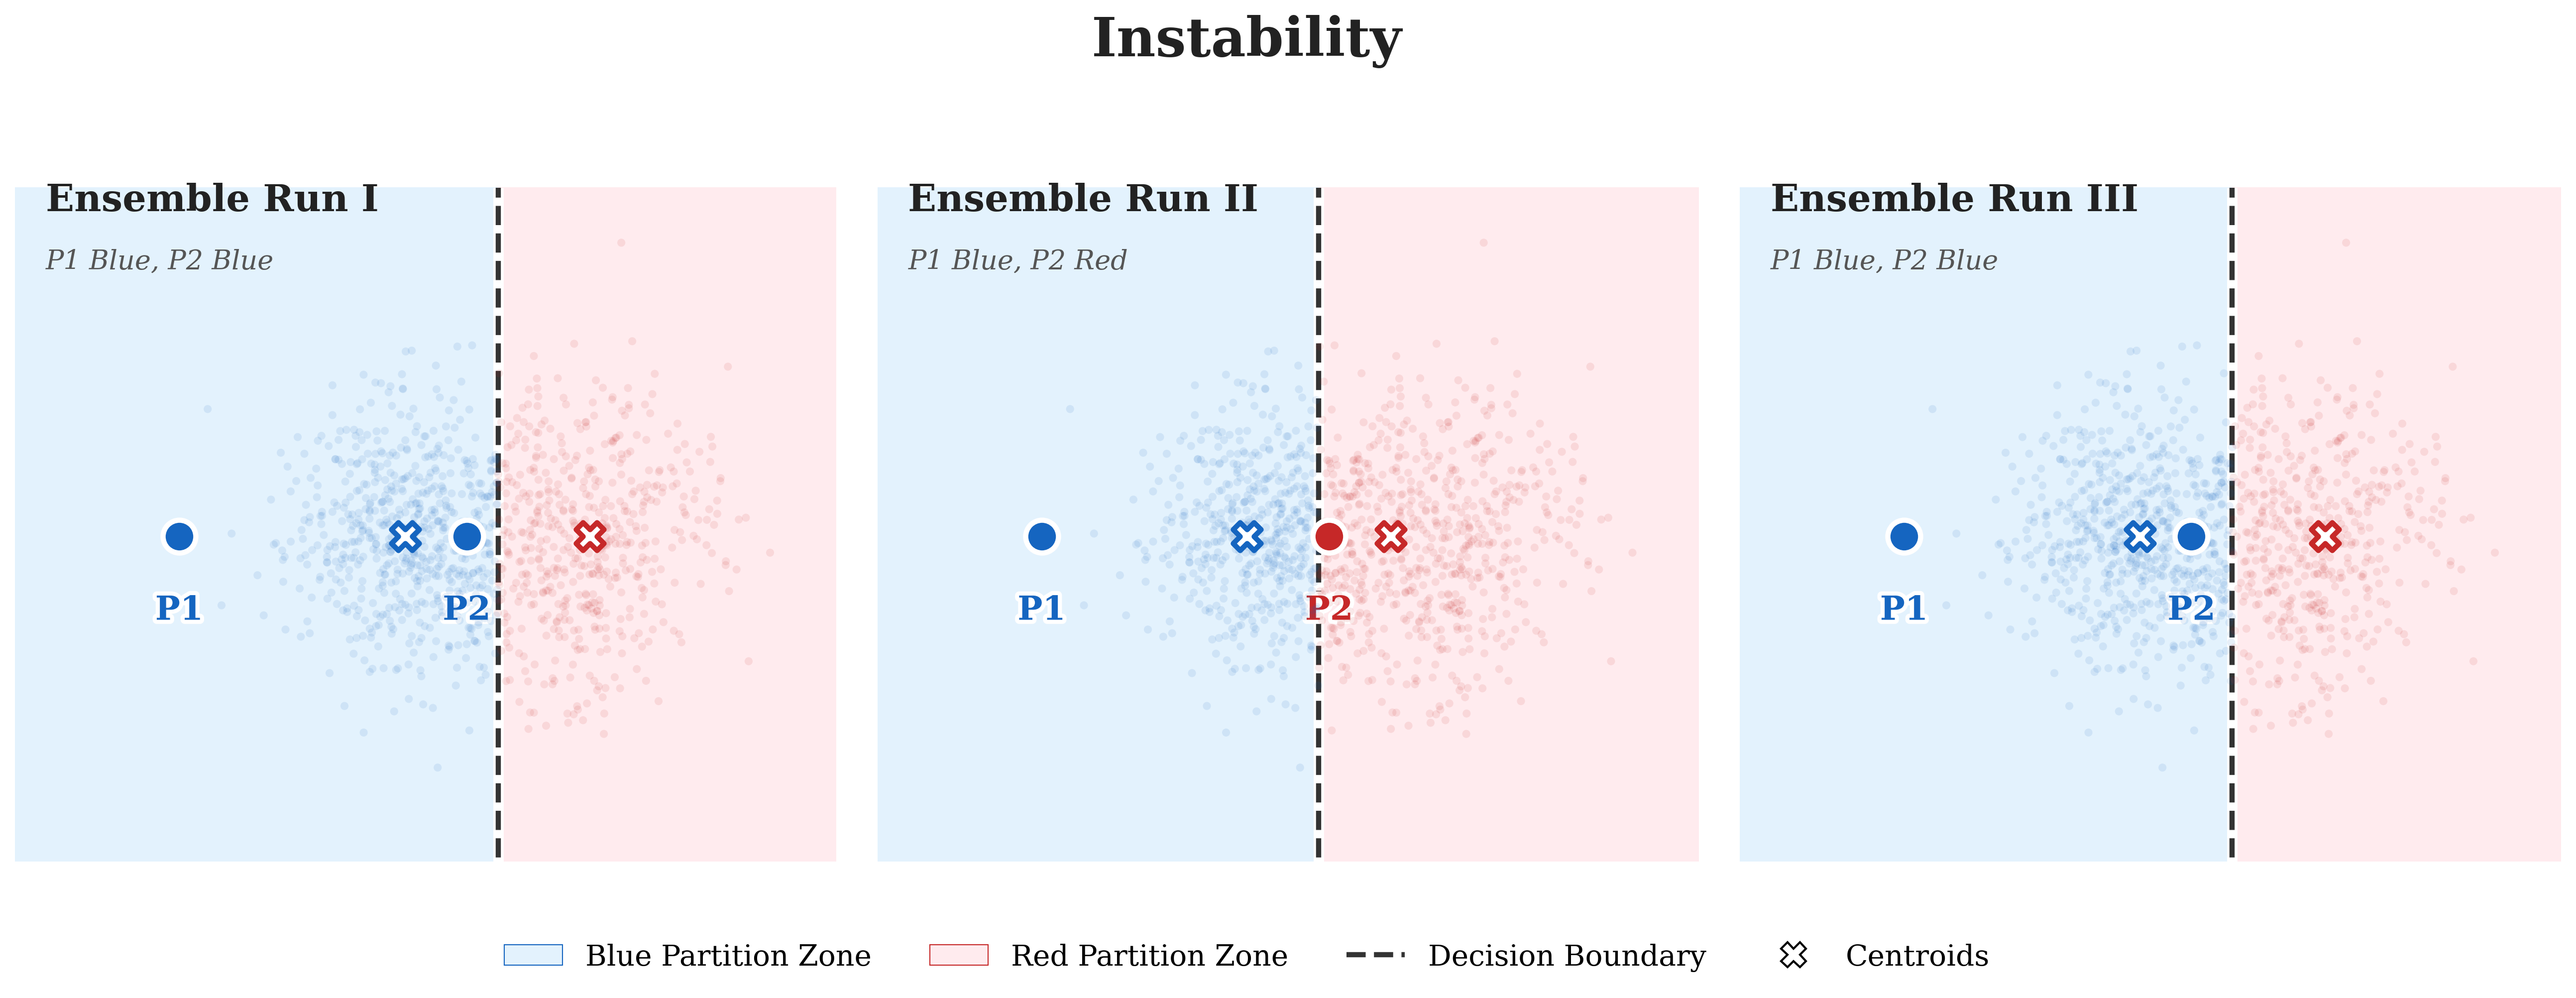

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
from matplotlib.patches import Patch, FancyBboxPatch
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe

font_names = [f.name for f in fm.fontManager.ttflist]
font_family = 'Times New Roman' if 'Times New Roman' in font_names else 'DejaVu Serif'

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': [font_family],
    'font.size': 14,
    'axes.titlesize': 18,
    'figure.titlesize': 24,
    'figure.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'text.usetex': False
})

np.random.seed(10)
N = 600

# Cluster A (Left - Blue)
x1 = np.random.normal(2.0, 0.6, N)
y1 = np.random.normal(2.0, 0.6, N)
# Cluster B (Right - Red)
x2 = np.random.normal(3.6, 0.7, N)
y2 = np.random.normal(2.0, 0.7, N)

# Filter for clean, distinct shapes
mask1 = (x1 < 3.0); x1, y1 = x1[mask1], y1[mask1]
mask2 = (x2 > 2.4); x2, y2 = x2[mask2], y2[mask2]

X_all = np.concatenate([x1, x2])
Y_all = np.concatenate([y1, y2])
XY = np.column_stack((X_all, Y_all))

# Special Points
P1 = np.array([-0.2, 2.0]) # Stable Anchor
P2 = np.array([2.6, 2.0])  # Unstable Variable

# ENSEMBLE SCENARIOS
# Run 1: Boundary to the RIGHT of P2 (P2 is Safe/Blue)
c1_blue = np.array([2.0, 2.0]); c1_red = np.array([3.8, 2.0])

# Run 2: Boundary to the LEFT of P2 (P2 is Exposed/Red) -> THE FLIP
c2_blue = np.array([1.8, 2.0]); c2_red = np.array([3.2, 2.0])

# Run 3: Boundary Far Right (P2 is Safe/Blue)
c3_blue = np.array([2.1, 2.0]); c3_red = np.array([3.9, 2.0])

scenarios = [
    (c1_blue, c1_red, "Ensemble Run I", "P1 Blue, P2 Blue"),
    (c2_blue, c2_red, "Ensemble Run II", "P1 Blue, P2 Red"),
    (c3_blue, c3_red, "Ensemble Run III", "P1 Blue, P2 Blue")
]

# PLOTTING FUNCTION
def plot_voronoi(ax, c_blue, c_red, title, subtitle):
    # A. VORONOI BACKGROUND (The Decision Space)
    xx, yy = np.mgrid[-2:7:400j, -1:5:400j]
    grid_pts = np.c_[xx.ravel(), yy.ravel()]

    d_blue = np.linalg.norm(grid_pts - c_blue, axis=1)
    d_red = np.linalg.norm(grid_pts - c_red, axis=1)
    mask = (d_red < d_blue).astype(int).reshape(xx.shape)

    # Blue Region: #E3F2FD, Red Region: #FFEBEE
    cmap = matplotlib.colors.ListedColormap(['#E3F2FD', '#FFEBEE'])
    ax.contourf(xx, yy, mask, levels=[-0.5, 0.5, 1.5], cmap=cmap, alpha=1.0, zorder=0)

    # B. DECISION BOUNDARY (The Mechanism)
    # White halo for contrast + Black dashed line
    ax.contour(xx, yy, mask, levels=[0.5], colors='white', linewidths=5, zorder=1)
    cs = ax.contour(xx, yy, mask, levels=[0.5], colors='#333333', linewidths=2.5, linestyles='--', zorder=2)

    # C. GHOST POINTS (Context)
    d0 = np.linalg.norm(XY - c_blue, axis=1)
    d1 = np.linalg.norm(XY - c_red, axis=1)
    lbls = (d1 < d0).astype(int)

    ax.scatter(X_all[lbls==0], Y_all[lbls==0], c='#1565C0', s=15, alpha=0.1, edgecolors='none', zorder=5)
    ax.scatter(X_all[lbls==1], Y_all[lbls==1], c='#C62828', s=15, alpha=0.1, edgecolors='none', zorder=5)

    # D. CENTROIDS (The Source)
    ax.scatter(*c_blue, s=180, marker='X', c='white', edgecolors='#1565C0', linewidth=2.5, zorder=10)
    ax.scatter(*c_red, s=180, marker='X', c='white', edgecolors='#C62828', linewidth=2.5, zorder=10)

    # E. SPECIAL POINTS (The Evidence)
    # P1: The Stable Anchor
    ax.scatter(*P1, s=250, c='#1565C0', edgecolors='white', linewidth=2.5, zorder=20)
    txt = ax.text(P1[0], P1[1]-0.5, "P1", ha='center', va='top', fontweight='bold', color='#1565C0', fontsize=16)
    txt.set_path_effects([pe.withStroke(linewidth=4, foreground='white')])

    # P2: The Unstable Flip
    p2_is_red = np.linalg.norm(P2 - c_red) < np.linalg.norm(P2 - c_blue)
    p2_col = '#C62828' if p2_is_red else '#1565C0'

    ax.scatter(*P2, s=250, c=p2_col, edgecolors='white', linewidth=2.5, zorder=20)
    txt = ax.text(P2[0], P2[1]-0.5, "P2", ha='center', va='top', fontweight='bold', color=p2_col, fontsize=16)
    txt.set_path_effects([pe.withStroke(linewidth=4, foreground='white')])

    t = ax.text(-1.5, 4.8, title, fontsize=18, fontweight='bold', color='#222222')
    if "FLIPPED" in subtitle:
        sub_col = '#C62828'
        weight = 'bold'
    else:
        sub_col = '#555555'
        weight = 'normal'

    ax.text(-1.5, 4.3, subtitle, fontsize=13, style='italic', color=sub_col, fontweight=weight)

    # Clean up
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlim(-1.8, 6.2); ax.set_ylim(-0.8, 5.5)

import matplotlib.colors
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for i, (cb, cr, t, st) in enumerate(scenarios):
    plot_voronoi(axes[i], cb, cr, t, st)

fig.suptitle("Instability", fontsize=26, fontweight='bold', y=0.96, color='#222222')

# Legend (Centered Bottom)
legend_elements = [
    Patch(facecolor='#E3F2FD', edgecolor='#1565C0', linewidth=0.5, label='Blue Partition Zone'),
    Patch(facecolor='#FFEBEE', edgecolor='#C62828', linewidth=0.5, label='Red Partition Zone'),
    Line2D([0], [0], color='#333333', linestyle='--', linewidth=2.5, label='Decision Boundary'),
    Line2D([0], [0], marker='X', color='w', markeredgecolor='black', label='Centroids', markersize=12)
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, frameon=False, fontsize=14, bbox_to_anchor=(0.5, 0.02))

plt.subplots_adjust(top=0.85, bottom=0.15, wspace=0.05)
plt.savefig('neurips_mechanism_perfection.png', dpi=300, bbox_inches='tight')
plt.show()